In [142]:
include("MiniCollectiveSpins.jl")
include("Functions_time_evol_decay_rate.jl")
using PyPlot
using Statistics
using JLD2

In [143]:
# Nbr of particles
N_list = [4]#[2:2:10;]
r = 5#10
d0_lb = 5e-10 # Minimum distance between the atoms (lower boundary) in m
λ = 421e-9
d0_lb = d0_lb / λ
# Quantization axis along z
e = [0, 0, 1.];

# Plots of the time evolution

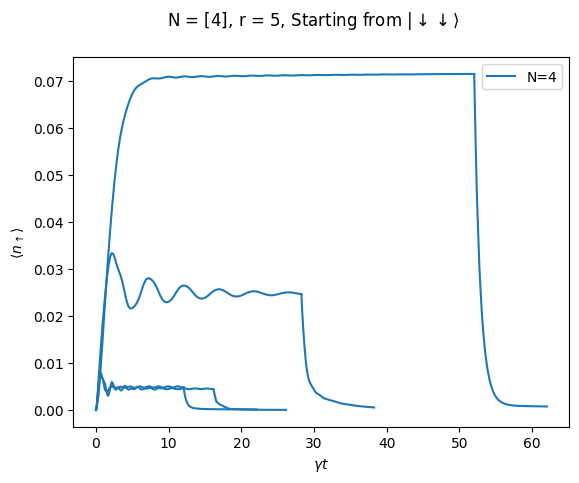

In [144]:
close("all")
fig, ax = subplots()
list_t_N_SS, popup_t_N_SS, nbr_error_t_N_SS, sol_t_N_SS = [], [], [], []
list_t_N_decay, popup_t_N_decay, nbr_error_t_N_decay, sol_t_N_decay = [], [], [], []
decay_rate_N_time = []

for (i, N) in enumerate(N_list)
    line = []
    # Load SS
    @load "SS/solutions/sol_N_$(N)_r_$(r).jld2" sol_tasks
    list_t_SS, popup_t_SS, nbr_error_SS, sol_t_SS =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N_SS, list_t_SS), push!(popup_t_N_SS, popup_t_SS), push!(nbr_error_t_N_SS, nbr_error_SS), push!(sol_t_N_SS, sol_t_SS)

    # Load decay
    @load "Decay/solutions/sol_N_$(N)_r_$(r).jld2" sol_tasks
    list_t_decay, popup_t_decay, nbr_error_decay, sol_t_decay =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N_decay, list_t_decay), push!(popup_t_N_decay, popup_t_decay), push!(nbr_error_t_N_decay, nbr_error_decay), push!(sol_t_N_decay, sol_t_decay)
    
    decay_rate_r_n = [] # Decay rate of each atom for each repetition
    counter = 1
    for j = 1:r
        if j ∉ nbr_error_SS && j ∉ nbr_error_decay
            for n = 1:N
                push!(decay_rate_r_n, (real(sol_t_decay[counter][2][n]-sol_t_decay[counter][1][n]))/(list_t_decay[counter][2]-list_t_decay[counter][1]))
            end
            counter += 1
        else
            push!(decay_rate_r_n, false)
        end
    end
    push!(decay_rate_N_time, decay_rate_r_n)

    counter_decay = 1
    for j in 1:length(popup_t_N_SS[i])
        if j ∉ nbr_error_t_N_SS[i]
            if line == []
                line, = ax.plot(list_t_SS[j], popup_t_SS[j], label="N=$(N_list[i])") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_SS[j], popup_t_SS[j], color=line.get_color()) # marker="o", markersize=1
            end
            ax.plot(list_t_SS[j][end] .+ list_t_decay[counter_decay], popup_t_decay[counter_decay], color=line.get_color())
            counter_decay += 1
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Load SS/parameters

In [145]:
u_SS_N, p0_N = [], []

for (i, N) in enumerate(N_list)
    u_SS_r, p0_r = [], []
    for j in 1:r
        u_SS = stationnary_state(N, r, j)
        push!(u_SS_r, u_SS)

        @load "SS/r0/r0_N_$(N)_r_$j.jdl2" r0 L
        push!(p0_r, compute_params(N, r0, e))
    end
    push!(u_SS_N, u_SS_r), push!(p0_N, p0_r)
end

# Compute the decay when laser shut down

In [146]:
deriv_N = []

for (i, N) in enumerate(N_list)
    deriv_r = []
    for j in 1:r
        if u_SS_N[i][j] != false
            du_SS = zeros(ComplexF64, length(u_SS_N[i][j]))
            libpath = "Decay/libs/liballfuncs_$N.dll"
            lib = Libdl.dlopen(libpath)
            sym = Libdl.dlsym(lib, "diffeqf")
            @ccall $sym(du_SS::Ptr{ComplexF64}, u_SS_N[i][j]::Ptr{ComplexF64}, p0_N[i][j]::Ptr{ComplexF64})::Cvoid
            Libdl.dlclose(lib)
            push!(deriv_r, real(du_SS[1:N]))
        else
            push!(deriv_r, false)
        end
    end
    push!(deriv_N, deriv_r)
end

# Plots

In [151]:
close("all")
fig, ax = subplots()

for (i, N) in enumerate(N_list)
    pts = []
    counter = 1
    for j in 1:r
        if deriv_N[i][j] != false
            for n = 1:N
                # if pts == []
                #     pts = ax.scatter(N, real(deriv_N[i][j][n]))
                # else
                #     ax.scatter(N, real(deriv_N[i][j][n]), color=pts.get_facecolor())
                # end

                pts = ax.scatter(N, real(deriv_N[i][j][n]))
                ax.scatter(N, decay_rate_N_time[i][counter], color=pts.get_facecolor(), marker="^")
                counter += 1
            end
        end
    end
end

ax.set_xlabel("N")
ax.set_ylabel("Derivative of each atom")
# pygui(false); gcf();
pygui(true); show()

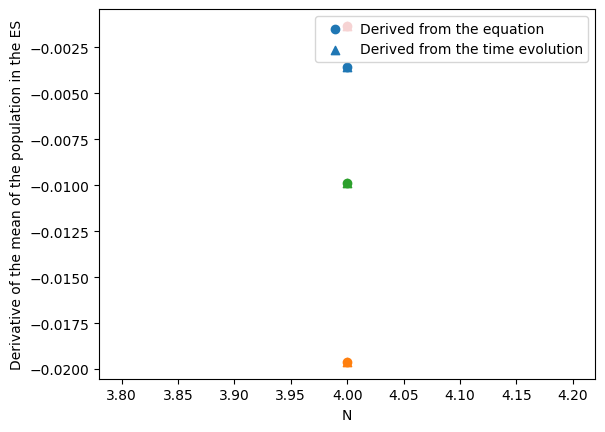

In [148]:
close("all")
fig, ax = subplots()

for (i, N) in enumerate(N_list)
    pts = []
    counter = 1
    for j in 1:r
        if deriv_N[i][j] != false
            # if pts == []
                pts = ax.scatter(N, mean(deriv_N[i][j]))
            # else
            #     ax.scatter(N, mean(deriv_N[i][j]), color=pts.get_facecolor())
            # end
            ax.scatter(N, (popup_t_N_decay[i][counter][2]-popup_t_N_decay[i][counter][1])/(N*(list_t_N_decay[i][counter][2]-list_t_N_decay[i][counter][1])), color=pts.get_facecolor(), marker="^")
            counter += 1
        end
    end
end

ax.set_xlabel("N")
ax.set_ylabel("Derivative of the mean of the population in the ES")
ax.legend(["Derived from the equation", "Derived from the time evolution"])
pygui(false); gcf();
# pygui(true); show()